# Red Neuronal Densa (MLP) sobre features tabulares

Entrenamos y evaluamos un **MLP (perceptrón multicapa)** — una red neuronal *feedforward* — sobre las **features tabulares por época** (`epoch_features.csv`): un vector de descriptores ya calculados para cada ventana de 30 s (features de HR, HRV y acelerometría, más contexto de épocas vecinas). El modelo recibe ese vector y predice la etapa de sueño (Wake, N1, N2, N3, REM).

In [7]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

from src.MLP import MLP, get_dataloaders, train_model, predict

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Preprocesamiento y partición

Un MLP requiere dos pasos que preparan los datos tabulares:

1. **Imputación de NaN.** Las features de contexto (`_lag`, `_lead`, `_delta`, `_rmean`, `_rstd`) quedan como `NaN` en los bordes de cada noche. Una red densa propaga los `NaN`, así que se imputan con la **mediana** de cada feature, calculada **sólo sobre train**.
2. **Estandarización.** Las features viven en escalas muy distintas (bpm, g, fracciones, conteos); un `StandardScaler` (media 0, desvío 1) evita que las de mayor magnitud dominen el gradiente. También **fiteado sólo en train**.

**Partición.** Se divide **por paciente** (`GroupShuffleSplit` sobre `subject`): dev/test 80/20 y dentro de dev train/val 80/20. Particionar por paciente (y no por época) evita fuga de información, porque las épocas de una misma noche están muy correlacionadas.

**Desbalance.** N2 domina y N1 es escasa. Se pasan pesos por clase a la `CrossEntropyLoss`, pero **suavizados** (`weight_mode='sqrt'`, la raíz de los pesos balanceados): los pesos `balanced` puros sobre-predicen las clases chicas y hunden la accuracy y el kappa; la versión `sqrt` es un punto intermedio que mejora esas métricas manteniendo un recall razonable en las minoritarias.

In [33]:
train_loader, val_loader, test_loader, class_weights, dreem_test, input_dim = get_dataloaders(
    batch_size=256, random_state=42, weight_mode="sqrt"
)

CSV: ../data_extraction/epoch_features.csv
Features: 122 | train: 123495  val: 37566  test: 47427
Class weights (sqrt): {0: 1.368, 1: 1.771, 2: 0.733, 3: 1.018, 4: 0.869}


## Arquitectura del MLP

Bloques densos `Linear -> BatchNorm -> ReLU -> Dropout` (256 -> 128 -> 64) y una capa final a las 5 etapas:

- **Entrada**: vector de features por época (`input_dim`).
- `BatchNorm1d` estabiliza el entrenamiento; `Dropout(0.3)` regulariza.
- **Salida**: 5 logits; la `CrossEntropyLoss` aplica el softmax internamente.

In [27]:
model = MLP(input_dim=input_dim, num_classes=5, hidden_dims=(256, 128, 64), dropout=0.5)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=122, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=64, out_features=5, bias=True)
  )
)


## Entrenamiento

Optimizador **Adam**, loss **ponderada por clase**, **`ReduceLROnPlateau`** (baja el lr si la val loss se estanca) y **early stopping** (restaura el mejor modelo según val loss).

## Elección de hiperparámetros

La arquitectura y el entrenamiento se eligieron buscando un modelo **simple y bien regularizado**. En datos tabulares una red densa suele rendir a la par de los árboles de gradiente, y agregar capacidad tiende a **sobreajustar** antes que a mejorar la generalización, así que se priorizó la regularización sobre el tamaño.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Capas ocultas | 256 → 128 → 64 | Embudo que comprime las ~122 features a una representación cada vez más compacta. Profundidad moderada: alcanza para capturar interacciones no lineales sin la tendencia a sobreajustar de redes más profundas sobre datos tabulares. |
| Activación | ReLU | Estándar, barata y sin saturación en redes feedforward. |
| `BatchNorm1d` | en cada capa oculta | Normaliza las activaciones intermedias: estabiliza y acelera el entrenamiento, clave con features de escalas mixtas (bpm, g, conteos). |
| Dropout | 0.3 | Las features de contexto (`_lag`/`_lead`/`_rmean`…) están muy correlacionadas y la red sobreajusta fácil; el dropout la fuerza a no depender de neuronas puntuales. |
| Optimizador | Adam | Robusto y poco sensible al ajuste inicial del learning rate. |
| Learning rate | 1e-3 | Default de Adam, buen punto de partida; el scheduler lo baja si hace falta. |
| `weight_decay` | 1e-4 | L2 leve que penaliza pesos grandes, complementa al dropout. |
| `batch_size` | 256 | Con ~123k épocas de train, batches grandes dan un gradiente estable y entrenan rápido. |
| Loss | CrossEntropy **ponderada (`sqrt`)** | Dataset muy desbalanceado (N2 ≫ N1). Se usan pesos por clase suavizados con raíz cuadrada: los `balanced` puros sobre-corrigen (suben F1-macro pero bajan accuracy/kappa), y `sqrt` equilibra mejor las tres métricas. |
| Scheduler | `ReduceLROnPlateau` (patience 5, factor 0.5) | Cuando la val loss se estanca, baja el lr a la mitad para afinar con pasos más chicos. |
| Early stopping | patience 10 | Corta si la val loss no mejora en 12 epochs y **restaura el mejor modelo**. |
| `epochs` | 100 (techo) | Sólo un límite superior; el early stopping corta mucho antes. |

**Compromiso desbalance ↔ métricas.** Ponderar la loss mejora el *recall* de las clases chicas (sube el **F1-macro**) a costa de *accuracy* y *kappa*. El parámetro `weight_mode` controla ese dial: `'balanced'` (máximo F1-macro), `'sqrt'` (equilibrio, usado acá) o `'none'` (máxima accuracy/kappa). Elegimos `'sqrt'` para subir accuracy y kappa sin resignar del todo las clases chicas.

In [29]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    epochs=100,
    lr=1e-3,
    patience=10,
    model_path="../data_extraction/best_mlp.pth",
)

Epoch   1 | Train Loss: 1.2325 | Val Loss: 1.2395 | Val Acc: 0.501
Epoch   2 | Train Loss: 1.2234 | Val Loss: 1.2377 | Val Acc: 0.503
Epoch   3 | Train Loss: 1.2189 | Val Loss: 1.2356 | Val Acc: 0.504
Epoch   4 | Train Loss: 1.2173 | Val Loss: 1.2405 | Val Acc: 0.497
Epoch   5 | Train Loss: 1.2160 | Val Loss: 1.2333 | Val Acc: 0.507
Epoch   6 | Train Loss: 1.2136 | Val Loss: 1.2321 | Val Acc: 0.506
Epoch   7 | Train Loss: 1.2109 | Val Loss: 1.2365 | Val Acc: 0.509
Epoch   8 | Train Loss: 1.2103 | Val Loss: 1.2326 | Val Acc: 0.511
Epoch   9 | Train Loss: 1.2072 | Val Loss: 1.2360 | Val Acc: 0.504
Epoch  10 | Train Loss: 1.2049 | Val Loss: 1.2387 | Val Acc: 0.505
Epoch  11 | Train Loss: 1.2055 | Val Loss: 1.2358 | Val Acc: 0.511
Epoch  12 | Train Loss: 1.2019 | Val Loss: 1.2287 | Val Acc: 0.511
Epoch  13 | Train Loss: 1.2010 | Val Loss: 1.2359 | Val Acc: 0.506
Epoch  14 | Train Loss: 1.1998 | Val Loss: 1.2287 | Val Acc: 0.510
Epoch  15 | Train Loss: 1.2004 | Val Loss: 1.2344 | Val Acc: 0

### Curva de loss (train vs. validación)

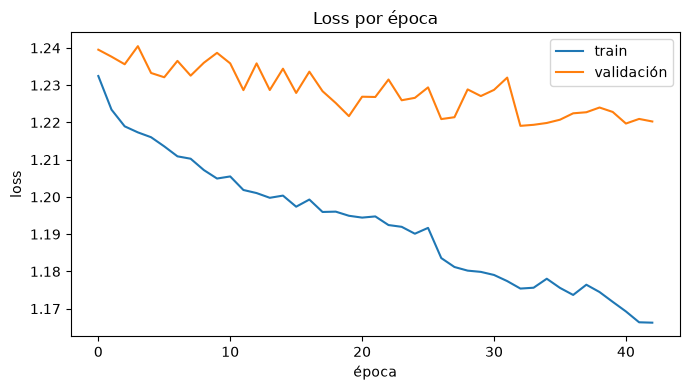

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='validación')
plt.xlabel('época')
plt.ylabel('loss')
plt.title('Loss por época')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas en test

Sobre el conjunto de **test** reportamos **Accuracy**, **F1-score (macro)** y **Cohen's Kappa** de las predicciones contra la etiqueta del experto (el target). El F1-macro (promedio simple por clase) y el kappa (descuenta el acierto por azar sobre la mayoritaria) son las métricas honestas bajo desbalance.

Como **comparativa**, agregamos a **Dreem**: su etiquetado automático basado en EEG, evaluado también contra el Expert. Dreem es un dispositivo dedicado (mucho más informativo que HR + acelerometría), así que sus métricas funcionan como una **cota de referencia alta**. Para que sea justo, ambos se evalúan sobre las mismas épocas: aquellas donde Dreem produjo etiqueta (descartando sus *Unknown*).

In [34]:
y_true, y_pred = predict(model, test_loader)

def resumen(nombre, y_t, y_p):
    acc = accuracy_score(y_t, y_p)
    f1 = f1_score(y_t, y_p, average='macro')
    kappa = cohen_kappa_score(y_t, y_p)
    print(f"{nombre:20} Accuracy {acc:.3f} | F1-macro {f1:.3f} | Kappa {kappa:.3f}")

# MLP sobre todo el test (vs Expert)
resumen("MLP (test completo)", y_true, y_pred)

# Comparativa vs Expert sobre las épocas donde Dreem produjo etiqueta (dreem != 5),
# evaluando ambos predictores contra el Expert (ground truth)
mask = dreem_test != 5
print(f"\nComparativa vs Expert (épocas con Dreem válido: {mask.sum()} de {len(mask)}):")
resumen("  MLP", y_true[mask], y_pred[mask])
resumen("  Dreem", y_true[mask], dreem_test[mask])

MLP (test completo)  Accuracy 0.529 | F1-macro 0.479 | Kappa 0.373

Comparativa vs Expert (épocas con Dreem válido: 47379 de 47427):
  MLP                Accuracy 0.530 | F1-macro 0.479 | Kappa 0.374
  Dreem              Accuracy 0.827 | F1-macro 0.729 | Kappa 0.766
